## Supplemental Figures 4 and 5
for WUS CMIP6 WARMING PAPER

In [1]:
import netCDF4
#import h5netcdf
import xarray as xr
import scipy
import os
os.environ['ESMFMKFILE'] = '/home/tessj/miniconda3/envs/xarrayxesmf/lib/esmf.mk'
import xesmf as xe
import numpy as np
#import xeofs as xeo
import scipy.stats as stats
import warnings
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd
import cartopy.crs as ccrs
import cartopy
import seaborn as sns
import matplotlib.colors as mcolors


def fix_coords_lon(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby(['longitude','latitude'])
    return ds

def fix_coords_lon_lat(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby(['lon','lat'])
    return ds

import statsmodels.api as sm
import json

### open dict of ensemble members

In [2]:
modmembers_geq3_tas = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_tas_total.json', 'r') as file:
        modmembers_geq3_tas = json.load(file)
        
modmembers_geq3_lwd = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_lwd_total.json', 'r') as file:
        modmembers_geq3_lwd = json.load(file)

modmembers_geq3_prw = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_prw_total.json', 'r') as file:
        modmembers_geq3_prw = json.load(file)

In [3]:
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_pl_total.json', 'r') as file:
        modmembers_all = json.load(file)
        

In [4]:
# make land mask
tas_test = xr.open_dataset(f'/d3/tessj/data/CMIP6/for_tess/ACCESS-ESM1-5/tas_Amon_ACCESS-ESM1-5_historical_r3i1p1f1_18500101-20141231_regrid.nc').sel(time=slice('1941-01-01', '2014-12-31'))
landmask = fix_coords_lon(xr.open_dataarray('/home/tessj/wildfire-clim/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask = landmask.interp_like(tas_test)
landmask = landmask.where(landmask>0.4, np.nan)
landmask = landmask/landmask

In [5]:
wusbox = [-125, -102, 32,  49]

In [6]:
weights = np.cos(np.deg2rad(landmask.lat))

In [7]:
datetimes_np64 = np.arange('1941-01', '2025-01', dtype='datetime64[M]')
datetimes_np64 = datetimes_np64.astype('datetime64[ns]')

### Open GISS and Berkeley observational data

In [8]:
gisstemp = xr.open_dataset('/home/tessj/wus_temp_trends/gistemp250_GHCNv4.nc').sel(time=slice('1941-01-01', '2024-12-31')).assign_coords({'time':datetimes_np64}).drop('time_bnds')

In [9]:
gisstemp_wus = gisstemp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
gisstemp_weights = np.cos(np.deg2rad(gisstemp.lat))

gisstemp_wus_avg = gisstemp_wus.weighted(gisstemp_weights).mean(['lon','lat'])
gisstemp_globland_avg = gisstemp.weighted(gisstemp_weights).mean(['lon','lat'])

In [10]:
gisstemp_wus_avg_szn = {}
gisstemp_globland_avg_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    gisstemp_wus_avg_szn[szn] = gisstemp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    gisstemp_globland_avg_szn[szn] = gisstemp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [12]:
berk_temp = xr.open_dataset('/home/tessj/wus_temp_trends/Complete_TAVG_LatLong1.nc', decode_times=True).isel(time=slice(12*191,3300)).assign_coords({'time':gisstemp.time}).rename({'latitude':'lat', 'longitude':'lon'})

In [13]:
berk_temp_wus = berk_temp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
berk_temp_na = berk_temp.sel(lon=slice(wusbox[0],-90), lat=slice(20,60))

berk_temp_weights = np.cos(np.deg2rad(berk_temp.lat))

berk_temp_wus_avg = berk_temp_wus.weighted(berk_temp_weights).mean(['lon','lat'])
berk_temp_globland_avg = berk_temp.weighted(berk_temp_weights).mean(['lon','lat'])

In [82]:
berk_temp_wus_avg_trend = berk_temp_wus_avg.sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
berk_temp_globland_avg_trend = berk_temp_globland_avg.sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [16]:
berk_temp_wus_avg_szn = {}
berk_temp_globland_avg_szn = {}
berk_temp_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_szn[szn] = berk_temp_na.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_wus_avg_szn[szn] = berk_temp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_globland_avg_szn[szn] = berk_temp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [83]:
berk_temp_wus_avg_trend_szn = {}
berk_temp_globland_avg_trend_szn = {}
berk_temp_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_avg_trend_szn[szn] = berk_temp_wus_avg_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_globland_avg_trend_szn[szn] = berk_temp_globland_avg_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_wus_trend_szn[szn] = berk_temp_wus_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### Open CMIP6 data

In [18]:
ds_tas_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_avgs.nc')
ds_tas_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_na.nc')

In [19]:
ds_lwd_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_lwd_avgs.nc')
ds_lwd_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_lwd_na.nc')

In [20]:
ds_prw_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_prw_avgs.nc')
ds_prw_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_prw_na.nc')

In [21]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim


In [22]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim

ds_tas_avg_m_clim = ds_tas_avg.groupby('time.month').mean('time')
ds_tas_avg_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_m_clim

In [23]:
ds_tas_wus_51_80_m_clim = ds_tas_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_wus_51_80_m_anom = ds_tas_wus.groupby('time.month') - ds_tas_wus_51_80_m_clim

In [24]:
ds_tas_avg_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_szn[szn] = ds_tas_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [84]:
ds_tas_avg_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_trend_szn[szn] = ds_tas_avg_51_80_m_anom_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [26]:
ds_lwd_wus_51_80_m_clim = ds_lwd_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_wus_51_80_m_anom = ds_lwd_wus.groupby('time.month') - ds_lwd_wus_51_80_m_clim

In [27]:
ds_prw_wus_51_80_m_clim = ds_prw_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_prw_wus_51_80_m_anom = ds_prw_wus.groupby('time.month') - ds_prw_wus_51_80_m_clim

In [28]:
ds_lwd_wus_51_80_m_anom_szn = {}
ds_prw_wus_51_80_m_anom_szn = {}


for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_wus_51_80_m_anom_szn[szn] = ds_lwd_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    
    ds_prw_wus_51_80_m_anom_szn[szn] = ds_prw_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [85]:
ds_lwd_wus_51_80_m_anom_trend_szn = {}
ds_prw_wus_51_80_m_anom_trend_szn = {}


for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_wus_51_80_m_anom_trend_szn[szn] = ds_lwd_wus_51_80_m_anom_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_prw_wus_51_80_m_anom_trend_szn[szn] = ds_prw_wus_51_80_m_anom_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [86]:
ds_tas_wus_51_80_m_anom_szn = {}
ds_tas_wus_51_80_m_anom_trend_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_wus_51_80_m_anom_szn[szn] = ds_tas_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    
    ds_tas_wus_51_80_m_anom_trend_szn[szn] = ds_tas_wus_51_80_m_anom_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [31]:
ds_lwd_avg_51_80_m_clim = ds_lwd_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_avg_51_80_m_anom = ds_lwd_avg.groupby('time.month') - ds_lwd_avg_51_80_m_clim

ds_prw_avg_51_80_m_clim = ds_prw_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_prw_avg_51_80_m_anom = ds_prw_avg.groupby('time.month') - ds_prw_avg_51_80_m_clim

In [32]:
ds_lwd_avg_51_80_m_anom_szn = {}
ds_prw_avg_51_80_m_anom_szn = {}


for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_avg_51_80_m_anom_szn[szn] = ds_lwd_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    ds_prw_avg_51_80_m_anom_szn[szn] = ds_prw_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    


In [87]:
ds_lwd_avg_51_80_m_anom_trend_szn = {}
ds_prw_avg_51_80_m_anom_trend_szn = {}


for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_avg_51_80_m_anom_trend_szn[szn] = ds_lwd_avg_51_80_m_anom_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    ds_prw_avg_51_80_m_anom_trend_szn[szn] = ds_prw_avg_51_80_m_anom_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### Open ERA5 data

In [34]:
era5_sl_wus= xr.open_dataset('/home/tessj/wus_temp_trends/era5_slvars_1940_2024_na.nc')[['tp', 'z','e', 't2m','d2m','sp']].load()

In [35]:
era5_lwd = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_msdwlwrf_1940_2025.nc').load()

In [36]:
era5_lwd = fix_coords_lon(era5_lwd).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])

In [38]:
#era5_sl_wus = era5_sl_wus.drop('avg_sdlwrf').isel(time=slice(None,None,2))

In [37]:
era5_lwd = era5_lwd.assign_coords(time=era5_sl_wus.time)

In [38]:
era5_sl_wus = xr.merge([era5_sl_wus, era5_lwd.sel(lat=slice(0,65), lon=slice(-180, -80))])

In [40]:
era5_tcwv = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_tcwv_1940_2025.nc')[['tcwv']].load()
era5_tcwv = fix_coords_lon(era5_tcwv).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).drop(['number', 'expver'])

In [41]:
era5_tcwv = era5_tcwv.assign_coords(time=era5_sl_wus.time)

In [42]:
era5_sl_wus = xr.merge([era5_sl_wus, era5_tcwv.sel(lat=slice(0,65), lon=slice(-180, -80))])

In [43]:
era5_weights = np.cos(np.deg2rad(era5_sl_wus.lat))
landmask = fix_coords_lon(xr.open_dataarray('/net/kage/d4/naomi/DataCatalog/ERA5/monthly/single_level/y1979-2020/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask = landmask.where(landmask>0.4, np.nan)
landmask = landmask/landmask

In [44]:
era5_sl_wus_51_80_m_clim = era5_sl_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
era5_sl_wus_51_80_m_anom = era5_sl_wus.groupby('time.month') - era5_sl_wus_51_80_m_clim

In [45]:
era5_sl_wus_avg_51_80_m_clim = era5_sl_wus_51_80_m_clim.where(landmask==landmask).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3])).weighted(era5_weights).mean(['lon', 'lat'])


In [46]:
era5_sl_wus_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_szn[szn] = era5_sl_wus_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [88]:
era5_sl_wus_51_80_m_trend = era5_sl_wus_51_80_m_anom.sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
era5_sl_wus_51_80_m_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_trend_szn[szn] = era5_sl_wus_51_80_m_anom_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [48]:
era5_sl_wus_51_80_m_anom_avg = era5_sl_wus_51_80_m_anom.where(landmask==landmask).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3])).weighted(era5_weights).mean(['lon', 'lat'])

In [49]:
era5_sl_wus_51_80_m_anom_avg_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_avg_szn[szn] = era5_sl_wus_51_80_m_anom_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [89]:
era5_sl_wus_51_80_m_anom_avg_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    era5_sl_wus_51_80_m_anom_avg_trend_szn[szn] = era5_sl_wus_51_80_m_anom_avg_szn[szn].sel(time=slice('1960-01-01','2024-12-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### Open CAM6 SST-forced model data

In [52]:
cam6_lwd_mean = xr.open_dataset(f'http://hodges.ldeo.columbia.edu:81/SOURCES/.CAM6/.forRichard/.CAM6/.runs/.ensemble-extension-to-aug2021/.atm/.mean/.SLD/.FLDS.nc/.FLDS/dods',
                               decode_times=False)
cam6_lwd_mean

<xarray.Dataset>
Dimensions:  (lat: 96, time: 512, lon: 144)
Coordinates:
  * lat      (lat) float32 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * time     (time) float32 0.5 1.5 2.5 3.5 4.5 ... 508.5 509.5 510.5 511.5
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Data variables:
    FLDS     (time, lat, lon) float32 ...
Attributes:
    Conventions:  IRIDL

In [53]:
cam6_prw_mean = xr.open_dataset(f'http://hodges.ldeo.columbia.edu:81/SOURCES/.CAM6/.forRichard/.CAM6/.runs/.ensemble-extension-to-aug2021/.atm/.mean/.SLD/.TMQ.nc/.TMQ/dods',
                               decode_times=False)
cam6_prw_mean

<xarray.Dataset>
Dimensions:  (lat: 96, time: 512, lon: 144)
Coordinates:
  * lat      (lat) float32 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * time     (time) float32 0.5 1.5 2.5 3.5 4.5 ... 508.5 509.5 510.5 511.5
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Data variables:
    TMQ      (time, lat, lon) float32 ...
Attributes:
    Conventions:  IRIDL

In [54]:
import cftime
def to_dt64(ds, timevar='time', unit='months since 1979-01-01'):
    ds[timevar] = cftime.num2date(ds[timevar], unit, '360_day')
    ds[timevar] = ds.indexes[timevar].to_datetimeindex()
    return ds

In [55]:
cam6_lwd_mean = fix_coords_lon_lat(cam6_lwd_mean)

In [56]:
cam6_lwd_mean = to_dt64(cam6_lwd_mean)

/tmp/ipykernel_12955/3691984310.py:4: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, '360_day', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds[timevar] = ds.indexes[timevar].to_datetimeindex()


In [57]:
cam6_prw_mean = fix_coords_lon_lat(cam6_prw_mean)
cam6_prw_mean = to_dt64(cam6_prw_mean)

/tmp/ipykernel_12955/3691984310.py:4: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, '360_day', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds[timevar] = ds.indexes[timevar].to_datetimeindex()


In [58]:
cam6_ds_t2m = xr.open_dataarray('/d4/tessj/data/CAM6/monthly/trefht_ens.nc')
cam6_ds_t2m = fix_coords_lon_lat(cam6_ds_t2m)

In [59]:
landmask = fix_coords_lon(xr.open_dataarray('/home/tessj/wildfire-clim/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask = landmask.interp_like(tas_test)
landmask = landmask.where(landmask>0.4, np.nan)
landmask = landmask/landmask

In [60]:
cam6_landmask = landmask.interp_like(cam6_ds_t2m)

In [61]:
cam6_ds_t2m_m_clim = cam6_ds_t2m.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')
cam6_ds_t2m_anom = cam6_ds_t2m.groupby('time.month') - cam6_ds_t2m_m_clim

In [62]:
cam6_ds_t2m_wus = cam6_ds_t2m_anom.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
cam6_ds_t2m_weights = np.cos(np.deg2rad(cam6_ds_t2m.lat))
cam6_ds_t2m_wus_avg = cam6_ds_t2m_wus.where(cam6_landmask==cam6_landmask).weighted(cam6_ds_t2m_weights).mean(['lon','lat'])
cam6_ds_t2m_na = cam6_ds_t2m_anom.sel(lat=slice(0,65), lon=slice(-180,-80))

cam6_ds_t2m_globland_avg = cam6_ds_t2m_anom.where(cam6_landmask==cam6_landmask).weighted(cam6_ds_t2m_weights).mean(['lon','lat'])

cam6_ds_t2m_wus = cam6_ds_t2m_na

In [63]:
cam6_ds_t2m_wus_avg_trend = cam6_ds_t2m_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
cam6_ds_t2m_globland_avg_trend = cam6_ds_t2m_globland_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [64]:
cam6_ds_t2m_wus_avg_szn = {}
cam6_ds_t2m_globland_avg_szn = {}
cam6_ds_t2m_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_t2m_wus_szn[szn] = cam6_ds_t2m_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_ds_t2m_wus_avg_szn[szn] = cam6_ds_t2m_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_ds_t2m_globland_avg_szn[szn] = cam6_ds_t2m_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [65]:
cam6_ds_t2m_wus_avg_trend_szn = {}
cam6_ds_t2m_globland_avg_trend_szn = {}
cam6_ds_t2m_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_t2m_wus_avg_trend_szn[szn] = cam6_ds_t2m_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_t2m_globland_avg_trend_szn[szn] = cam6_ds_t2m_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_t2m_wus_trend_szn[szn] = cam6_ds_t2m_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [66]:
cam6_ds_t2m_wus_avg_ensmean_szn = {}
cam6_ds_t2m_globland_avg_ensmean_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_t2m_wus_avg_ensmean_szn[szn] = cam6_ds_t2m_wus_avg.mean('member').resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))    
    cam6_ds_t2m_globland_avg_ensmean_szn[szn] = cam6_ds_t2m_globland_avg.mean('member').resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [67]:
cam6_ds_t2m_wus_avg_trend_ensmean_szn = {}
cam6_ds_t2m_globland_avg_trend_ensmean_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_ds_t2m_wus_avg_trend_ensmean_szn[szn] = cam6_ds_t2m_wus_avg_ensmean_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_ds_t2m_globland_avg_trend_ensmean_szn[szn] = cam6_ds_t2m_globland_avg_ensmean_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [68]:
cam6_lwd_mean_m_clim = cam6_lwd_mean.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')
cam6_lwd_mean_anom = cam6_lwd_mean.groupby('time.month') - cam6_lwd_mean_m_clim

In [69]:
cam6_lwd_mean_wus = cam6_lwd_mean.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
cam6_lwd_mean_weights = np.cos(np.deg2rad(cam6_lwd_mean.lat))
cam6_lwd_mean_wus_avg = cam6_lwd_mean_wus.where(cam6_landmask==cam6_landmask).weighted(cam6_lwd_mean_weights).mean(['lon','lat'])
cam6_lwd_mean_globland_avg = cam6_lwd_mean.where(cam6_landmask==cam6_landmask).weighted(cam6_lwd_mean_weights).mean(['lon','lat'])

cam6_lwd_mean_na = cam6_lwd_mean_anom.sel(lat=slice(0,65), lon=slice(-180,-80))

#being lazy
cam6_lwd_mean_wus = cam6_lwd_mean_na

In [70]:
cam6_lwd_mean_wus_avg_trend = cam6_lwd_mean_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
cam6_lwd_mean_globland_avg_trend = cam6_lwd_mean_globland_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [71]:
cam6_lwd_mean_wus_avg_szn = {}
cam6_lwd_mean_globland_avg_szn = {}
cam6_lwd_mean_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_lwd_mean_wus_szn[szn] = cam6_lwd_mean_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_lwd_mean_wus_avg_szn[szn] = cam6_lwd_mean_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_lwd_mean_globland_avg_szn[szn] = cam6_lwd_mean_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [72]:
cam6_lwd_mean_wus_avg_trend_szn = {}
cam6_lwd_mean_globland_avg_trend_szn = {}
cam6_lwd_mean_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_lwd_mean_wus_avg_trend_szn[szn] = cam6_lwd_mean_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_lwd_mean_globland_avg_trend_szn[szn] = cam6_lwd_mean_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_lwd_mean_wus_trend_szn[szn] = cam6_lwd_mean_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [73]:
cam6_prw_mean_m_clim = cam6_prw_mean.sel(time=slice('1979-01-01', '2000-01-01')).groupby('time.month').mean('time')
cam6_prw_mean_anom = cam6_prw_mean.groupby('time.month') - cam6_prw_mean_m_clim

In [74]:
cam6_prw_mean_wus = cam6_prw_mean.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
cam6_prw_mean_weights = np.cos(np.deg2rad(cam6_prw_mean.lat))
cam6_prw_mean_wus_avg = cam6_prw_mean_wus.where(cam6_landmask==cam6_landmask).weighted(cam6_prw_mean_weights).mean(['lon','lat'])
cam6_prw_mean_globland_avg = cam6_prw_mean.where(cam6_landmask==cam6_landmask).weighted(cam6_prw_mean_weights).mean(['lon','lat'])

cam6_prw_mean_na = cam6_prw_mean_anom.sel(lat=slice(0,65), lon=slice(-180,-80))

#being lazy
cam6_prw_mean_wus = cam6_prw_mean_na

In [75]:
cam6_prw_mean_wus_avg_trend = cam6_prw_mean_wus_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
cam6_prw_mean_globland_avg_trend = cam6_prw_mean_globland_avg.sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [76]:
cam6_prw_mean_wus_avg_szn = {}
cam6_prw_mean_globland_avg_szn = {}
cam6_prw_mean_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_prw_mean_wus_szn[szn] = cam6_prw_mean_wus.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_prw_mean_wus_avg_szn[szn] = cam6_prw_mean_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    cam6_prw_mean_globland_avg_szn[szn] = cam6_prw_mean_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [77]:
cam6_prw_mean_wus_avg_trend_szn = {}
cam6_prw_mean_globland_avg_trend_szn = {}
cam6_prw_mean_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    cam6_prw_mean_wus_avg_trend_szn[szn] = cam6_prw_mean_wus_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_prw_mean_globland_avg_trend_szn[szn] = cam6_prw_mean_globland_avg_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    cam6_prw_mean_wus_trend_szn[szn] = cam6_prw_mean_wus_szn[szn].sel(time=slice('1980-01-01','2021-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### Figure 2 panel a.

/tmp/ipykernel_22579/1149226150.py:10: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(2, 2,ii+1)


Text(0.0, 1.0, 'a.')

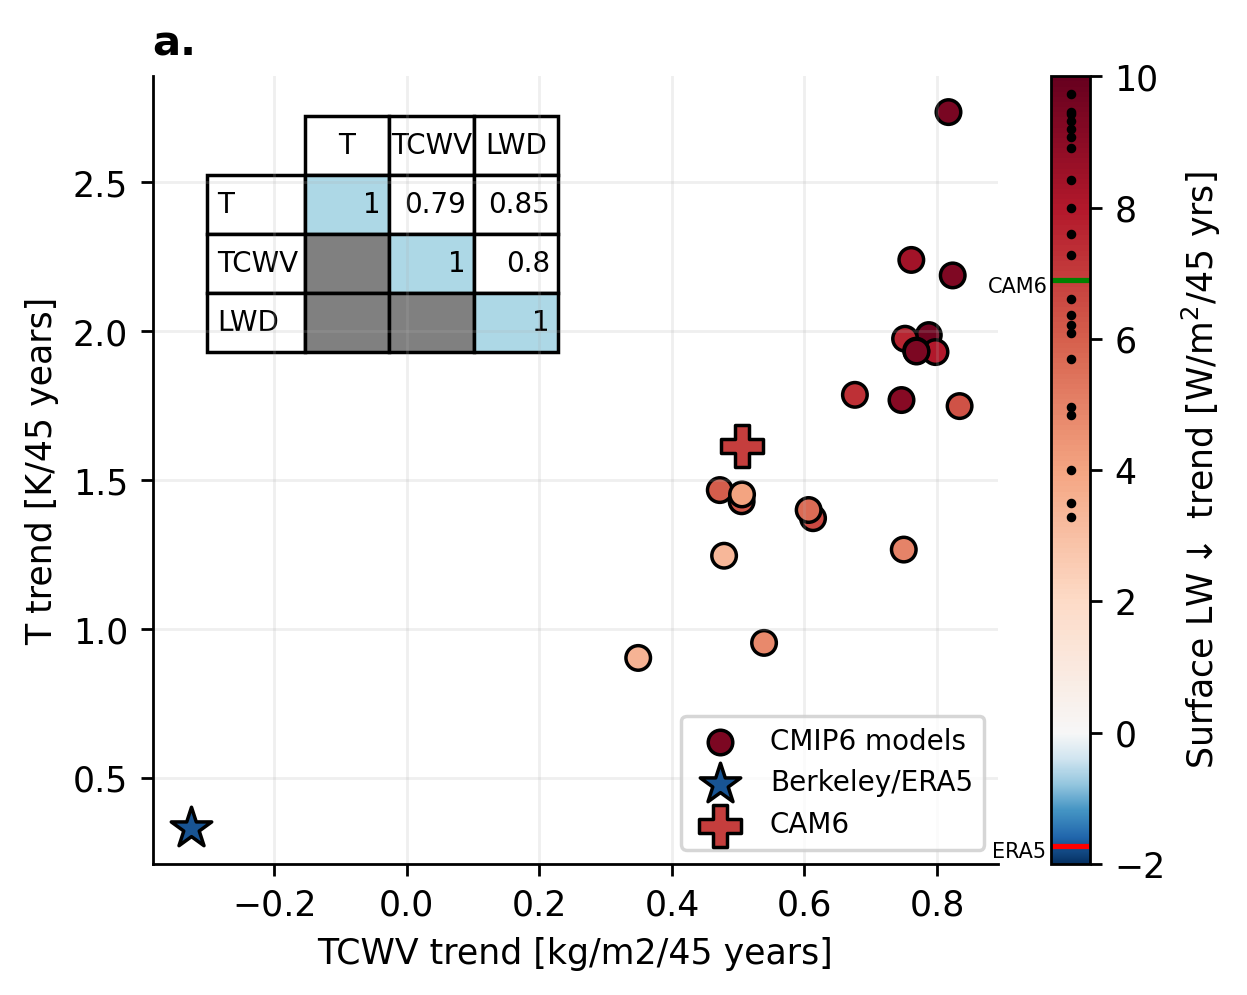

In [95]:

commonmodels = list(set(ds_prw_avg_51_80_m_anom_trend_szn['JFM'].model.values) & set(ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].model.values))

fig, axes = plt.subplots(1,1, figsize=(12,9), dpi=250)
szns = ['JFM', 'AMJ', 'JAS', 'OND']
vmins = [-2]
vmaxes = [10]
ii=0
norm = mcolors.TwoSlopeNorm(vmin=vmins[ii], vcenter=0, vmax=vmaxes[ii])

ax = plt.subplot(2, 2,ii+1)
szn = szns[ii]

sc = ax.scatter(y=45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model=commonmodels), x=45*ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model=commonmodels),
           marker='o',c=45*ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model=commonmodels), cmap='RdBu_r', norm=norm, edgecolor='k', s=50)

ax.scatter(y=45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model='CESM2'), x=45*ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model='CESM2'),
           marker='o',c=45*ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model='CESM2'), cmap='RdBu_r', norm=norm, edgecolor='k', s=50, label='CMIP6 models')

#ax.scatter(y=45*ds_tas_avg_51_80_m_anom_mmm_trend.tas_wus_polyfit_coefficients, x=45*ds_lw_avg_51_80_m_anom_mmm_trend.lw_globland_polyfit_coefficients, marker='X', s=150, c='k', label='CMIP6 MMM')
ax.scatter(y=45*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients, 
           x=45*(era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].tcwv_polyfit_coefficients), c=45*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].avg_sdlwrf_polyfit_coefficients, 
           s=150, cmap='RdBu_r', norm=norm, marker='*', edgecolor='k', label='Berkeley/ERA5')

ax.scatter(y=45*cam6_ds_t2m_wus_avg_trend_szn[szn].mean('member').polyfit_coefficients, 
       x=45*(cam6_prw_mean_wus_avg_trend_szn[szn].TMQ_polyfit_coefficients), c=45*cam6_lwd_mean_wus_avg_trend_szn[szn].FLDS_polyfit_coefficients, 
       s=150, cmap='RdBu_r',norm=norm, marker='P', edgecolor='k', label='CAM6')

#ax.axhline(45*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients, c='r', ls='--', alpha=0.6, zorder=0)
#ax.plot(np.arange(0,3.5), np.arange(0,3.5), c='k', label='1:1')
cb = plt.colorbar(sc, label='Surface LW$\downarrow$ trend [W/m$^2$/45 yrs]',  spacing='proportional')
cb.ax.set_yscale('linear')
cb.ax.axhline(45*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].avg_sdlwrf_polyfit_coefficients, c='r')
cb.ax.axhline(45*cam6_lwd_mean_wus_avg_trend_szn[szn].FLDS_polyfit_coefficients, c='g')
for model in ds_lwd_avg_51_80_m_anom_trend_szn[szn].model:
    cb.ax.plot(8, 45*ds_lwd_avg_51_80_m_anom_trend_szn[szn].sel(model=model).lwd_wus_polyfit_coefficients, 'k.', ms=3)
    
cb.ax.text(x=-1.5, y=-1.9, s='ERA5', fontsize=6)
cb.ax.text(x=-1.6, y=6.7, s='CAM6', fontsize=6)

for model in ds_lwd_avg_51_80_m_anom_trend_szn[szn].model:
    cb.ax.plot(.5, 45*ds_lwd_avg_51_80_m_anom_trend_szn[szn].sel(model=model).lwd_wus_polyfit_coefficients, 'k.', ms=3.5)

col_labels=['T','TCWV','LWD']
the_table = ax.table(colWidths=[0.1,0.1,0.1], 
                      cellText=[['1',str(round(xr.corr(ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model=commonmodels), ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model=commonmodels)).item(),2 )), 
                                 str(round(xr.corr(ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model=commonmodels), ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model=commonmodels)).item(),2))],['','1',
                                                                                                   str(round(xr.corr(ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model=commonmodels), ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model=commonmodels)).item(),2 ))],['','','1']],
                      rowColours = ['white', 'white', 'white'],
                      colColours = ['white', 'white', 'white'],
                      cellColours = [['lightblue', 'white', 'white'], ['grey', 'lightblue', 'white'], ['grey', 'grey', 'lightblue']],
                      rowLabels=col_labels,
                      colLabels=col_labels,
                      bbox = [0.18, 0.65, .3, .3])
the_table.auto_set_font_size(False)
the_table.set_fontsize(8)

ax.set_ylabel('T trend [K/45 years]')
ax.set_xlabel('TCWV trend [kg/m2/45 years]')
if ii==0: ax.legend(fontsize=8, loc='lower right')
#ax.set_ylim([0,4])
#ax.set_xlim(.8,3)
ax.grid(alpha=0.2) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title('')
ax.set_title('a.', loc='left', fontweight='bold')

### Supplemental figure 2

Text(0.5, 0.93, '1950-1979 Trends')

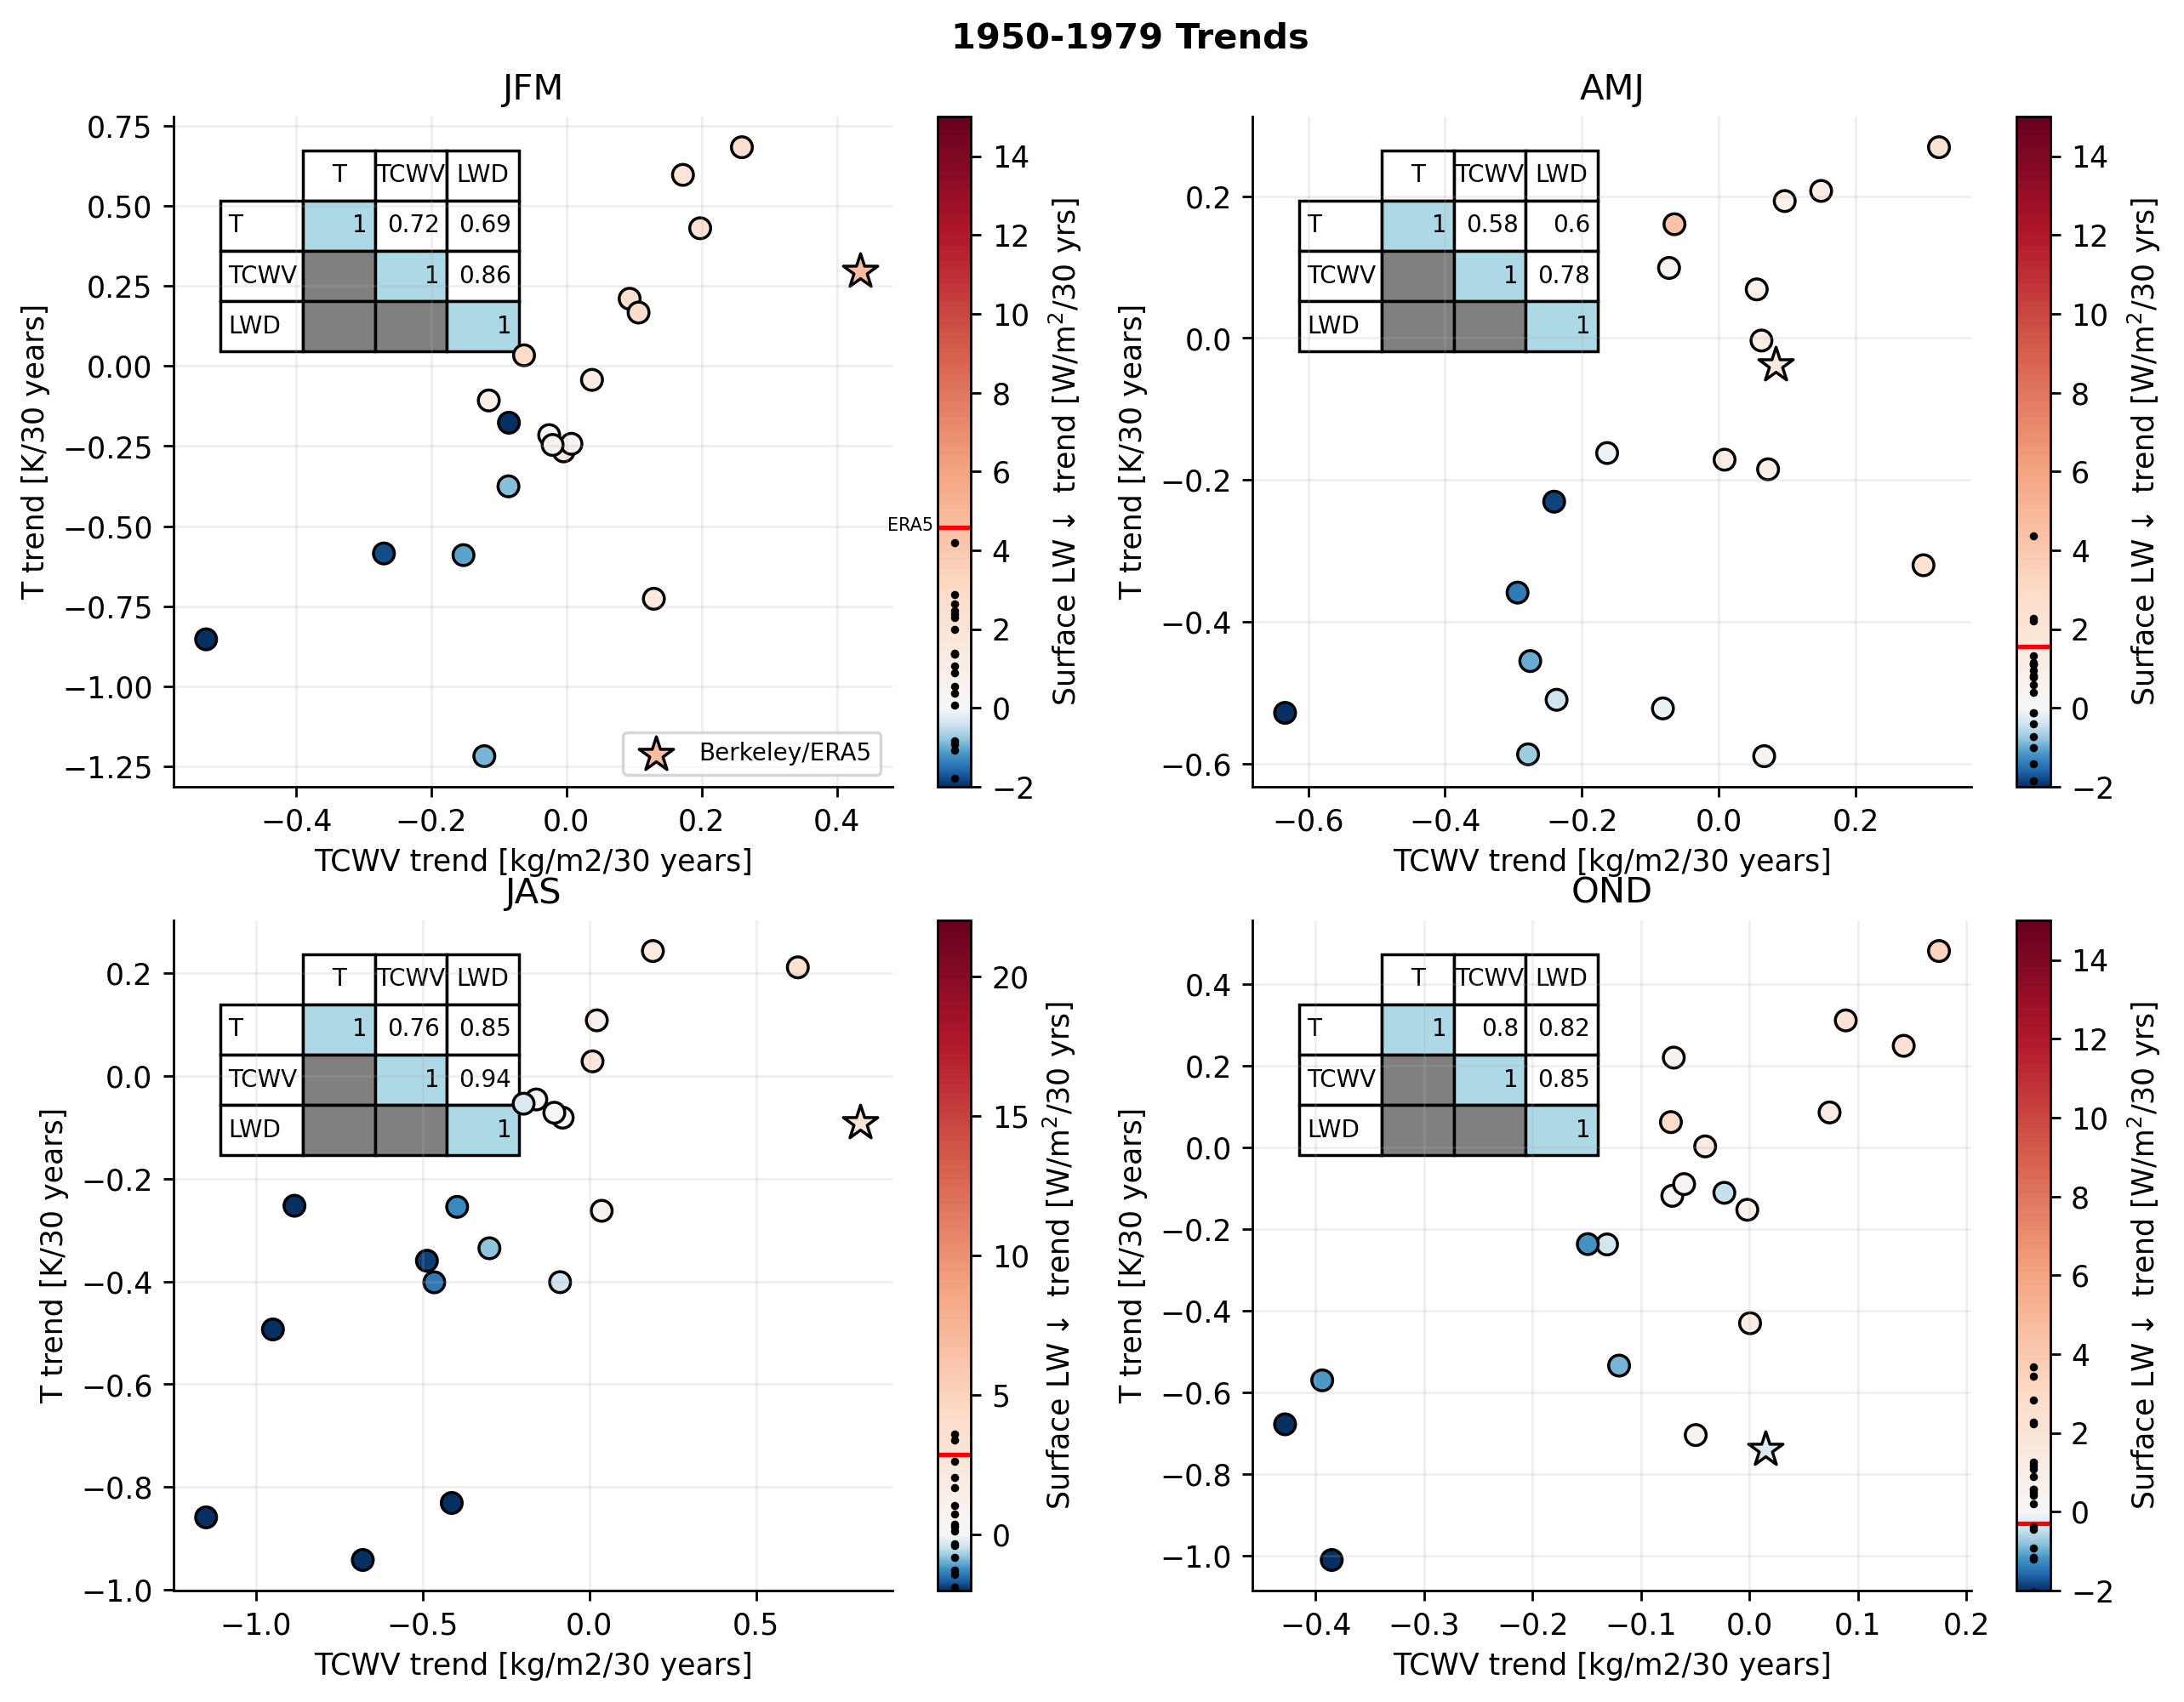

In [81]:
commonmodels = list(set(ds_prw_avg_51_80_m_anom_trend_szn['JFM'].model.values) & set(ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].model.values))

fig, axes = plt.subplots(2,2, figsize=(12,9), dpi=250)
szns = ['JFM', 'AMJ', 'JAS', 'OND']
vmins = [-2, -2, -2, -2]
vmaxes = [15, 15, 22, 15]
ii=0

for ii, ax in enumerate(axes.flatten()):
    ax = plt.subplot(2, 2,ii+1)
    szn = szns[ii]
    norm = mcolors.TwoSlopeNorm(vmin=vmins[ii], vcenter=0, vmax=vmaxes[ii])

    sc = ax.scatter(y=30*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model=commonmodels), x=30*ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model=commonmodels),
               marker='o',c=30*ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model=commonmodels), cmap='RdBu_r', norm=norm, edgecolor='k', s=50)

    #ax.scatter(y=30*ds_tas_avg_51_80_m_anom_mmm_trend.tas_wus_polyfit_coefficients, x=30*ds_lw_avg_51_80_m_anom_mmm_trend.lw_globland_polyfit_coefficients, marker='X', s=150, c='k', label='CMIP6 MMM')
    ax.scatter(y=30*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients, 
               x=30*(era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].tcwv_polyfit_coefficients), c=30*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].avg_sdlwrf_polyfit_coefficients, 
               s=150, cmap='RdBu_r', norm=norm, marker='*', edgecolor='k', label='Berkeley/ERA5')

    #ax.scatter(y=30*cam6_ds_t2m_wus_avg_trend_szn[szn].mean('member').polyfit_coefficients, 
    #       x=30*(cam6_prw_mean_wus_avg_trend_szn[szn].TMQ_polyfit_coefficients), c=30*cam6_lwd_mean_wus_avg_trend_szn[szn].FLDS_polyfit_coefficients, 
    #       s=150, cmap='RdBu_r',norm=norm, marker='P', edgecolor='k', label='CAM6')

    #ax.axhline(30*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients, c='r', ls='--', alpha=0.6, zorder=0)
    #ax.plot(np.arange(0,3.5), np.arange(0,3.5), c='k', label='1:1')
    cb = plt.colorbar(sc, label='Surface LW$\downarrow$ trend [W/m$^2$/30 yrs]',  spacing='proportional')
    cb.ax.set_yscale('linear')
    cb.ax.axhline(30*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].avg_sdlwrf_polyfit_coefficients, c='r')
    #cb.ax.axhline(30*cam6_lwd_mean_wus_avg_trend_szn[szn].FLDS_polyfit_coefficients, c='g')
    for model in ds_lwd_avg_51_80_m_anom_trend_szn[szn].model:
        cb.ax.plot(8, 30*ds_lwd_avg_51_80_m_anom_trend_szn[szn].sel(model=model).lwd_wus_polyfit_coefficients, 'k.', ms=3)
    
    if ii==0:
        cb.ax.text(x=-1.5, y=4.5, s='ERA5', fontsize=6)
        # cb.ax.text(x=-1.6, y=6.7, s='CAM6', fontsize=6)

    for model in ds_lwd_avg_51_80_m_anom_trend_szn[szn].model:
        cb.ax.plot(.5, 30*ds_lwd_avg_51_80_m_anom_trend_szn[szn].sel(model=model).lwd_wus_polyfit_coefficients, 'k.', ms=3.5)

    col_labels=['T','TCWV','LWD']
    the_table = ax.table(colWidths=[0.1,0.1,0.1], 
                          cellText=[['1',str(round(xr.corr(ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model=commonmodels), ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model=commonmodels)).item(),2 )), 
                                     str(round(xr.corr(ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model=commonmodels), ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model=commonmodels)).item(),2))],['','1',
                                                                                                       str(round(xr.corr(ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model=commonmodels), ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model=commonmodels)).item(),2 ))],['','','1']],
                          rowColours = ['white', 'white', 'white'],
                          colColours = ['white', 'white', 'white'],
                          cellColours = [['lightblue', 'white', 'white'], ['grey', 'lightblue', 'white'], ['grey', 'grey', 'lightblue']],
                          rowLabels=col_labels,
                          colLabels=col_labels,
                          bbox = [0.18, 0.65, .3, .3])
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(8)

    ax.set_ylabel('T trend [K/30 years]')
    ax.set_xlabel('TCWV trend [kg/m2/30 years]')
    if ii==0: ax.legend(fontsize=8, loc='lower right')
    #ax.set_ylim([0,4])
    #ax.set_xlim(.8,3)
    ax.grid(alpha=0.2) 
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(f'{szn}')

fig.suptitle('1950-1979 Trends', fontweight='bold', y=0.93)

Text(0.5, 0.93, '1960-2024 Trends')

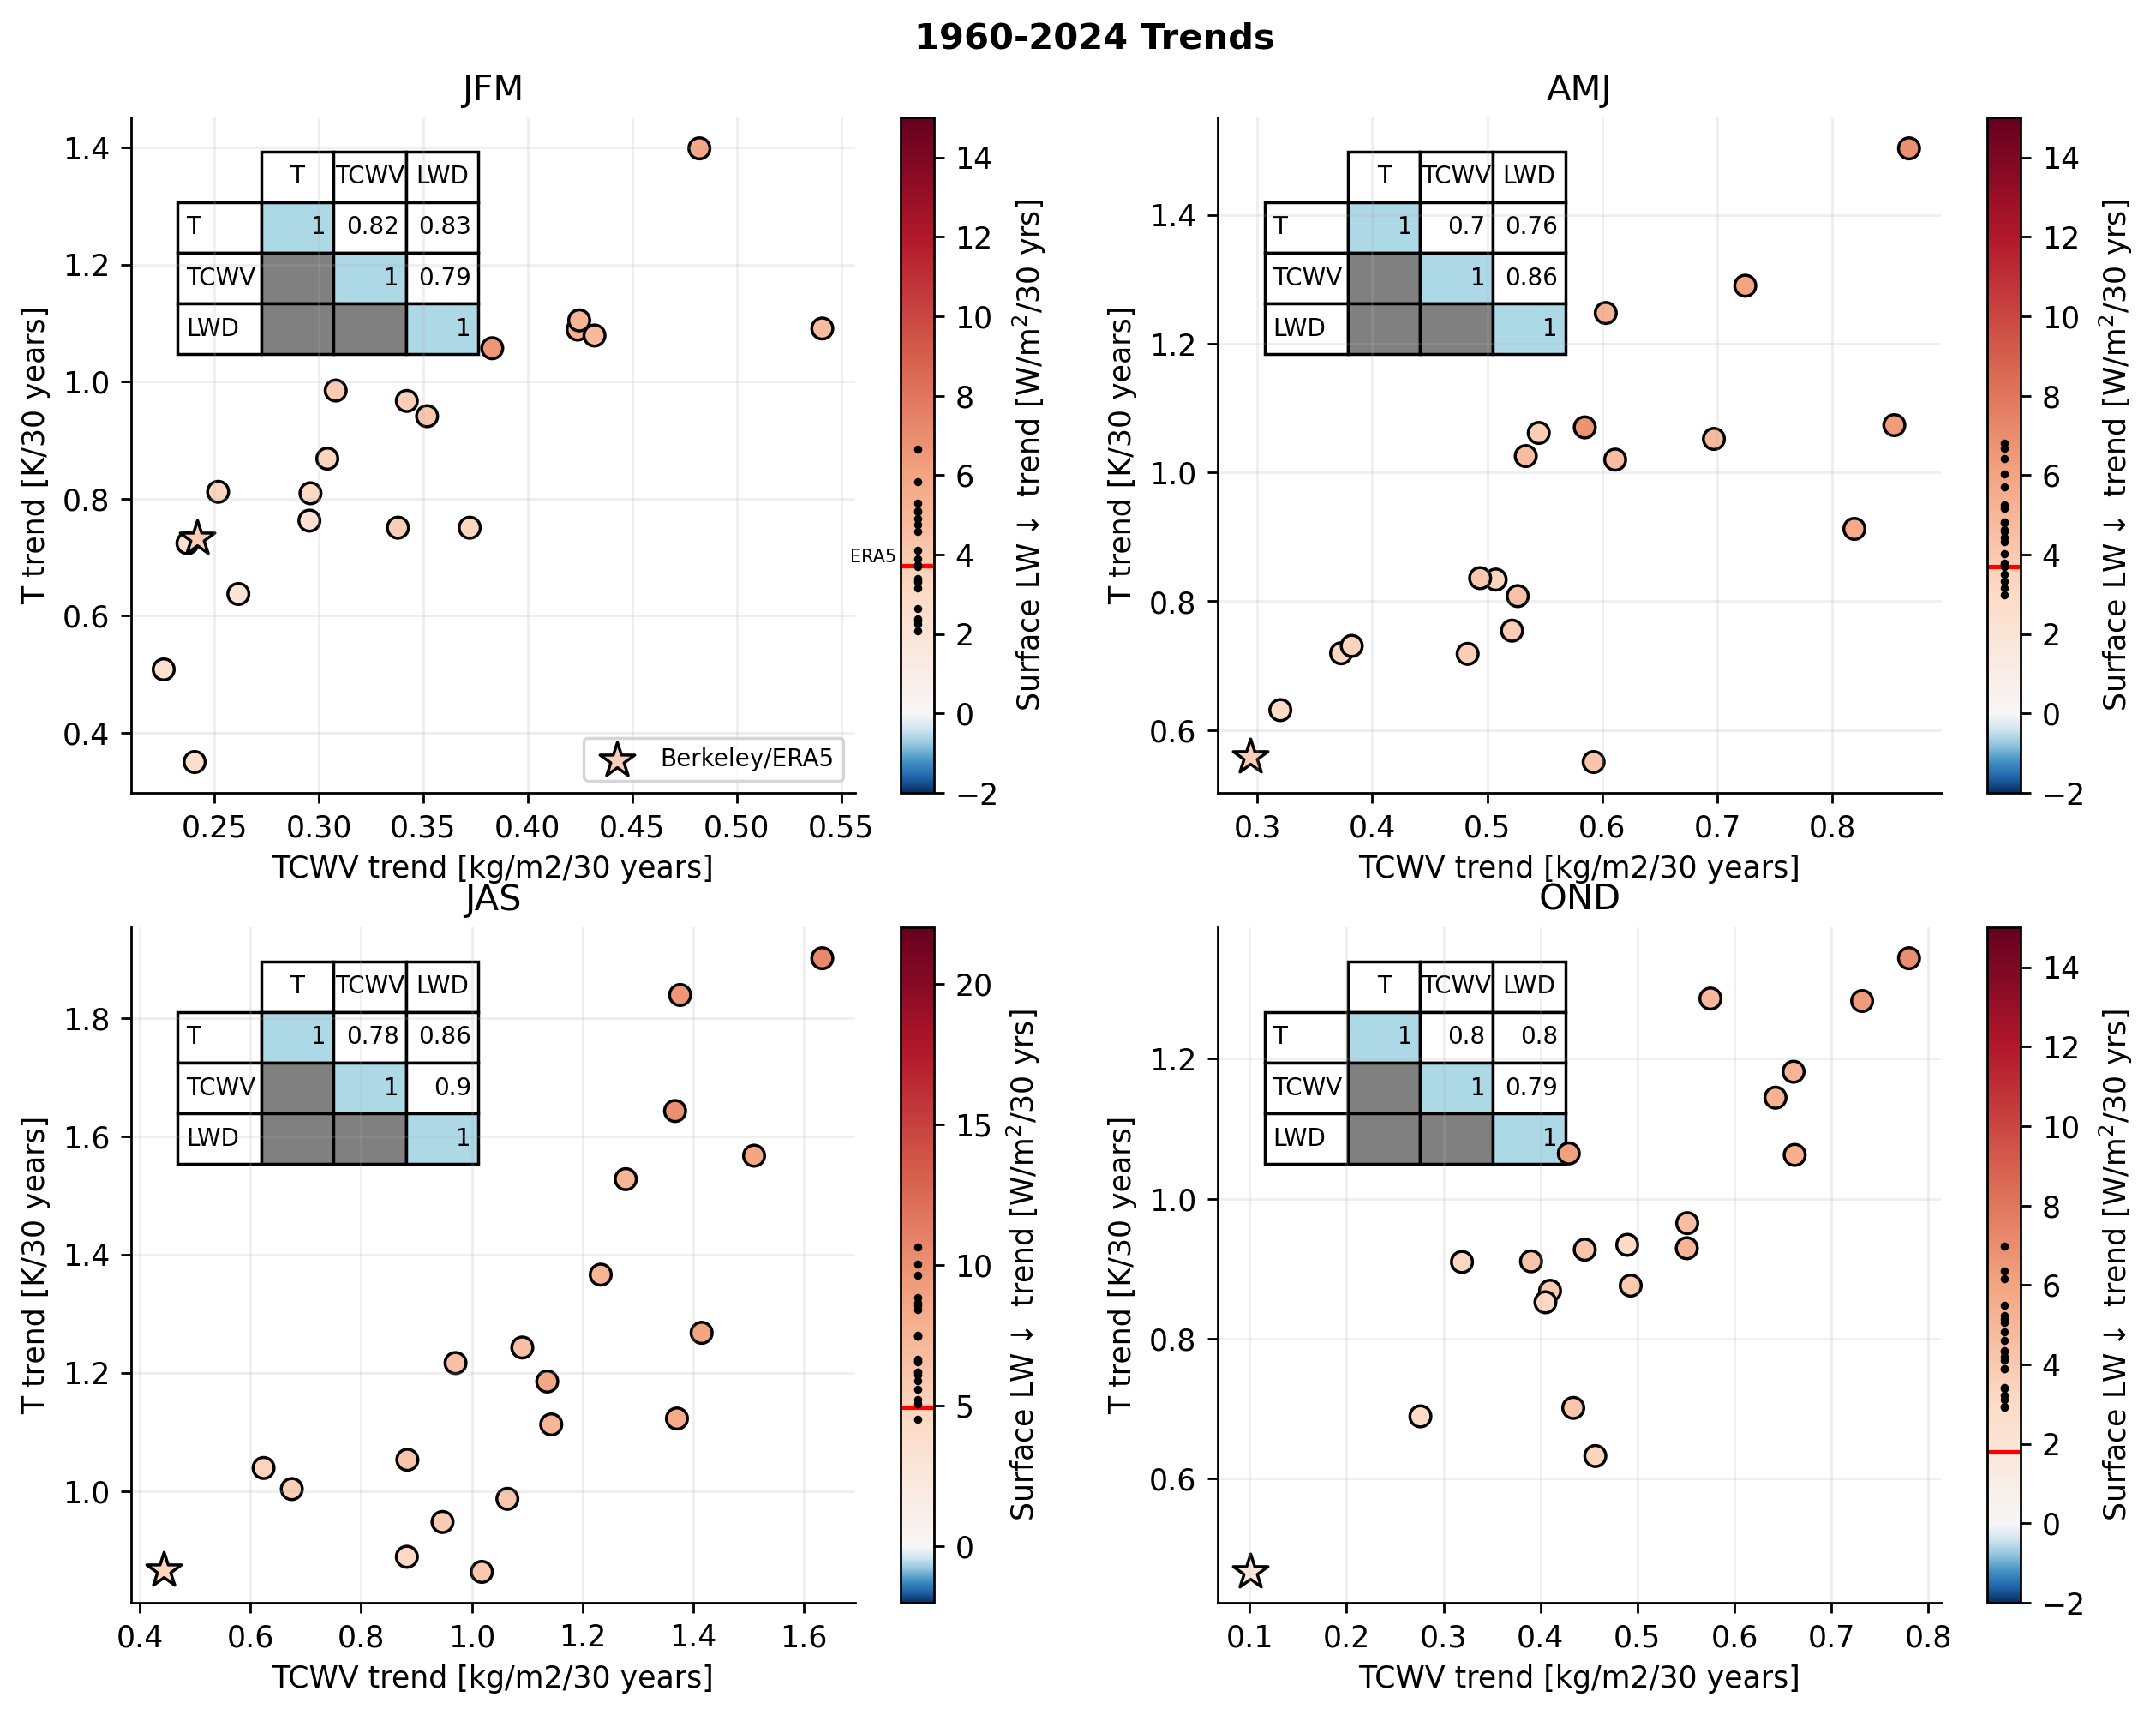

In [91]:
commonmodels = list(set(ds_prw_avg_51_80_m_anom_trend_szn['JFM'].model.values) & set(ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].model.values))

fig, axes = plt.subplots(2,2, figsize=(12,9), dpi=250)
szns = ['JFM', 'AMJ', 'JAS', 'OND']
vmins = [-2, -2, -2, -2]
vmaxes = [15, 15, 22, 15]
ii=0

for ii, ax in enumerate(axes.flatten()):
    ax = plt.subplot(2, 2,ii+1)
    szn = szns[ii]
    norm = mcolors.TwoSlopeNorm(vmin=vmins[ii], vcenter=0, vmax=vmaxes[ii])

    sc = ax.scatter(y=30*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model=commonmodels), x=30*ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model=commonmodels),
               marker='o',c=30*ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model=commonmodels), cmap='RdBu_r', norm=norm, edgecolor='k', s=50)

    #ax.scatter(y=30*ds_tas_avg_51_80_m_anom_mmm_trend.tas_wus_polyfit_coefficients, x=30*ds_lw_avg_51_80_m_anom_mmm_trend.lw_globland_polyfit_coefficients, marker='X', s=150, c='k', label='CMIP6 MMM')
    ax.scatter(y=30*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients, 
               x=30*(era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].tcwv_polyfit_coefficients), c=30*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].avg_sdlwrf_polyfit_coefficients, 
               s=150, cmap='RdBu_r', norm=norm, marker='*', edgecolor='k', label='Berkeley/ERA5')

    #ax.scatter(y=30*cam6_ds_t2m_wus_avg_trend_szn[szn].mean('member').polyfit_coefficients, 
    #       x=30*(cam6_prw_mean_wus_avg_trend_szn[szn].TMQ_polyfit_coefficients), c=30*cam6_lwd_mean_wus_avg_trend_szn[szn].FLDS_polyfit_coefficients, 
    #       s=150, cmap='RdBu_r',norm=norm, marker='P', edgecolor='k', label='CAM6')

    #ax.axhline(30*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients, c='r', ls='--', alpha=0.6, zorder=0)
    #ax.plot(np.arange(0,3.5), np.arange(0,3.5), c='k', label='1:1')
    cb = plt.colorbar(sc, label='Surface LW$\downarrow$ trend [W/m$^2$/30 yrs]',  spacing='proportional')
    cb.ax.set_yscale('linear')
    cb.ax.axhline(30*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].avg_sdlwrf_polyfit_coefficients, c='r')
    #cb.ax.axhline(30*cam6_lwd_mean_wus_avg_trend_szn[szn].FLDS_polyfit_coefficients, c='g')
    for model in ds_lwd_avg_51_80_m_anom_trend_szn[szn].model:
        cb.ax.plot(8, 30*ds_lwd_avg_51_80_m_anom_trend_szn[szn].sel(model=model).lwd_wus_polyfit_coefficients, 'k.', ms=3)
    
    if ii==0:
        cb.ax.text(x=-1.5, y=3.8, s='ERA5', fontsize=6)
        # cb.ax.text(x=-1.6, y=6.7, s='CAM6', fontsize=6)

    for model in ds_lwd_avg_51_80_m_anom_trend_szn[szn].model:
        cb.ax.plot(.5, 30*ds_lwd_avg_51_80_m_anom_trend_szn[szn].sel(model=model).lwd_wus_polyfit_coefficients, 'k.', ms=3.5)

    col_labels=['T','TCWV','LWD']
    the_table = ax.table(colWidths=[0.1,0.1,0.1], 
                          cellText=[['1',str(round(xr.corr(ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model=commonmodels), ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model=commonmodels)).item(),2 )), 
                                     str(round(xr.corr(ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.sel(model=commonmodels), ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model=commonmodels)).item(),2))],['','1',
                                                                                                       str(round(xr.corr(ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.sel(model=commonmodels), ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.sel(model=commonmodels)).item(),2 ))],['','','1']],
                          rowColours = ['white', 'white', 'white'],
                          colColours = ['white', 'white', 'white'],
                          cellColours = [['lightblue', 'white', 'white'], ['grey', 'lightblue', 'white'], ['grey', 'grey', 'lightblue']],
                          rowLabels=col_labels,
                          colLabels=col_labels,
                          bbox = [0.18, 0.65, .3, .3])
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(8)

    ax.set_ylabel('T trend [K/30 years]')
    ax.set_xlabel('TCWV trend [kg/m2/30 years]')
    if ii==0: ax.legend(fontsize=8, loc='lower right')
    #ax.set_ylim([0,4])
    #ax.set_xlim(.8,3)
    ax.grid(alpha=0.2) 
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(f'{szn}')

fig.suptitle('1960-2024 Trends', fontweight='bold', y=0.93)

### We choose to look at JFM because this is when the temperature trend discrepancy is largest (in terms of distance from ERA5 to the MMM and closest model ensemble mean), also when LWD discrepancy is largest (but not TCWV):

In [100]:
print('difference between CMIP6 MMM LWD and ERA5')
for szn in ds_lwd_avg_51_80_m_anom_trend_szn.keys():
    print(szn + ': ' + str((45*ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.mean() - 45*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].avg_sdlwrf_polyfit_coefficients).item()))

difference between CMIP6 MMM LWD and ERA5
JFM: 8.768555681755652
AMJ: 7.499738899903611
JAS: 6.548947712341376
OND: 6.93470982858334


In [102]:
print('difference between CMIP6 MMM T and ERA5')
for szn in ds_tas_avg_51_80_m_anom_trend_szn.keys():
    print(szn + ': ' + str((45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.mean() - 45*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].t2m_polyfit_coefficients).item()))

difference between CMIP6 MMM T and ERA5
JFM: 0.9622826849518383
AMJ: 0.6525307152654787
JAS: 0.08998367153114906
OND: 0.46647230808082507


In [32]:
print('difference between CMIP6 MMM T and Berk')
for szn in ds_tas_avg_51_80_m_anom_trend_szn.keys():
    print(szn + ': ' + str((45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.mean() - 45*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients).item()))

difference between CMIP6 MMM T and Berk
JFM: 1.30888956303842
AMJ: 1.1420295626050938
JAS: 0.5228259331861098
OND: 0.6512451633876435


In [101]:
print('difference between CMIP6 MMM TCWV and ERA5')
for szn in ds_prw_avg_51_80_m_anom_trend_szn.keys():
    print(szn + ': ' + str((45*ds_prw_avg_51_80_m_anom_trend_szn[szn].prw_wus_polyfit_coefficients.mean() - 45*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].tcwv_polyfit_coefficients).item()))

difference between CMIP6 MMM TCWV and ERA5
JFM: 0.9875043685830942
AMJ: 1.7235084311720437
JAS: 2.2854909892134576
OND: 0.9948196812086608


In [103]:
print('difference between CMIP6 min Tas and ERA5')
for szn in ds_tas_avg_51_80_m_anom_trend_szn.keys():
    print(szn + ': ' + str((45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.min() - 45*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].t2m_polyfit_coefficients).item()))

difference between CMIP6 min TCWV and ERA5
JFM: 0.22465759989845913
AMJ: -0.08618452710508295
JAS: -0.9293408519966935
OND: -0.33018839476248696


In [33]:
print('difference between CMIP6 min Tas and Berk')
for szn in ds_tas_avg_51_80_m_anom_trend_szn.keys():
    print(szn + ': ' + str((45*ds_tas_avg_51_80_m_anom_trend_szn[szn].tas_wus_polyfit_coefficients.min() - 45*berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients).item()))

difference between CMIP6 min Tas and Berk
JFM: 0.5712644779850409
AMJ: 0.4033143202345322
JAS: -0.4964985903417327
OND: -0.14541553945566854


In [104]:
print('difference between CMIP6 min LWD and ERA5')
for szn in ds_lwd_avg_51_80_m_anom_trend_szn.keys():
    print(szn + ': ' + str((45*ds_lwd_avg_51_80_m_anom_trend_szn[szn].lwd_wus_polyfit_coefficients.min() - 45*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].avg_sdlwrf_polyfit_coefficients).item()))

difference between CMIP6 min LWD and ERA5
JFM: 5.014562023162242
AMJ: 3.901619864810998
JAS: 1.0491344004248573
OND: 3.5348655009820065


In [89]:
45*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].avg_sdlwrf_polyfit_coefficients

<xarray.DataArray 'avg_sdlwrf_polyfit_coefficients' ()>
array(1.36816358)
Coordinates:
    degree   int64 1

In [113]:
45*era5_sl_wus_51_80_m_anom_avg_trend_szn[szn].t2m_polyfit_coefficients

<xarray.DataArray 't2m_polyfit_coefficients' ()>
array(0.67837589)
Coordinates:
    degree   int64 1

### Open pressure-level data for plotting panel b.

In [78]:
# data here is saved in cmip6_pl_subset_data_save.ipynb
cmip6_ta = xr.open_dataset('/d5/tessj/data/CMIP6/for_tess/WUS_subset_forpyrte/ta_WUSavg_19800101-20241231_allmodels.nc').resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')
cmip6_hus = xr.open_dataset('/d5/tessj/data/CMIP6/for_tess/WUS_subset_forpyrte/hus_WUSavg_19800101-20241231_allmodels.nc').resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')
#cmip6_zg = xr.open_dataset('/d5/tessj/data/CMIP6/for_tess/WUS_subset_forpyrte/zg_WUSavg_19800101-20241231_allmodels.nc')

In [79]:
cmip6_skt = xr.open_dataset('/d5/tessj/data/CMIP6/for_tess/WUS_subset_forpyrte/ts_WUSavg_19800101-20241231_allmodels.nc').resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')


In [80]:
cmip6_ta_trends = cmip6_ta.polyfit(dim='year', deg=1).sel(degree=1)
cmip6_ta_trends = cmip6_ta_trends.assign_coords({'plev':cmip6_ta_trends.plev*0.01}).rename({'plev':'pressure_level'})

In [81]:
cmip6_hus_trends = cmip6_hus.polyfit(dim='year', deg=1).sel(degree=1)
cmip6_hus_trends = cmip6_hus_trends.assign_coords({'plev':cmip6_hus_trends.plev*0.01}).rename({'plev':'pressure_level'})

In [82]:
cmip6_hus_80_00_avg = cmip6_hus.sel(year=slice(1980,2000)).mean('year').assign_coords({'plev':cmip6_hus.plev*0.01}).rename({'plev':'pressure_level'})
cmip6_hus_trends_frac = cmip6_hus_trends.rename({'hus_polyfit_coefficients':'hus'})/cmip6_hus_80_00_avg

In [83]:
gzt_wus = xr.open_dataset('/d5/tessj/data/ERA5/pressure_level/monthly/gzt_monthly_1980_2024_WUS.nc').drop('expver').drop('number')
gzt_wus = gzt_wus.weighted(weights=np.cos(np.deg2rad(gzt_wus.latitude))).mean(['latitude', 'longitude']).rename({'valid_time':'time'})

In [84]:
o3q_wus = xr.open_dataset('/d5/tessj/data/ERA5/pressure_level/monthly/o3q_monthly_1980_2024_WUS.nc').drop('expver').drop('number')
o3q_wus = o3q_wus.weighted(weights=np.cos(np.deg2rad(o3q_wus.latitude))).mean(['latitude', 'longitude']).rename({'valid_time':'time'})

In [85]:
skt_wus = xr.open_dataset('/d5/tessj/data/ERA5/pressure_level/monthly/skt_monthly_1980_2024_WUS.nc').drop('expver').drop('number')
skt_wus = skt_wus.weighted(weights=np.cos(np.deg2rad(skt_wus.latitude))).mean(['latitude', 'longitude']).rename({'valid_time':'time'})
skt_wus

<xarray.Dataset>
Dimensions:  (time: 540)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2024-12-01
Data variables:
    skt      (time) float64 272.4 275.4 277.3 283.6 ... 293.9 288.1 277.9 276.2

In [86]:
era5_lwd = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_msdwlwrf_1940_2025.nc')
era5_lwd = fix_coords_lon(era5_lwd).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2], wusbox[3])).drop(['number', 'expver']).load()
era5_lwd_jfm = era5_lwd.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')

In [87]:
landmask_era5 = fix_coords_lon(xr.open_dataarray('/home/tessj/wildfire-clim/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask_era5 = landmask_era5.where(landmask_era5>0.4, np.nan)
landmask_era5 = landmask_era5/landmask_era5

In [88]:
era5_weights = np.cos(np.deg2rad(era5_lwd_jfm.lat))
era5_wusavg_lwd = era5_lwd_jfm.where(landmask_era5==landmask_era5).weighted(era5_weights).mean(['lat','lon']).sel(year=slice(1980,2024)).avg_sdlwrf.values

In [89]:
era5_jfm = xr.merge([
    gzt_wus.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time'),
    o3q_wus.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time'),  
])

In [90]:
era5_jfm_80_00_avg = era5_jfm.sel(year=slice(1980,2000)).mean('year')

In [91]:
modmembers_all_noGISS = {k: v for k, v in modmembers_all.items() if k != 'GISS-E2-1-G'} 
modmembers_all_noGISS = {k: v for k, v in modmembers_all_noGISS.items() if k in commonmodels} 

## plot Figure 2 panel b.

Text(0.02, 0.99, 'b.')

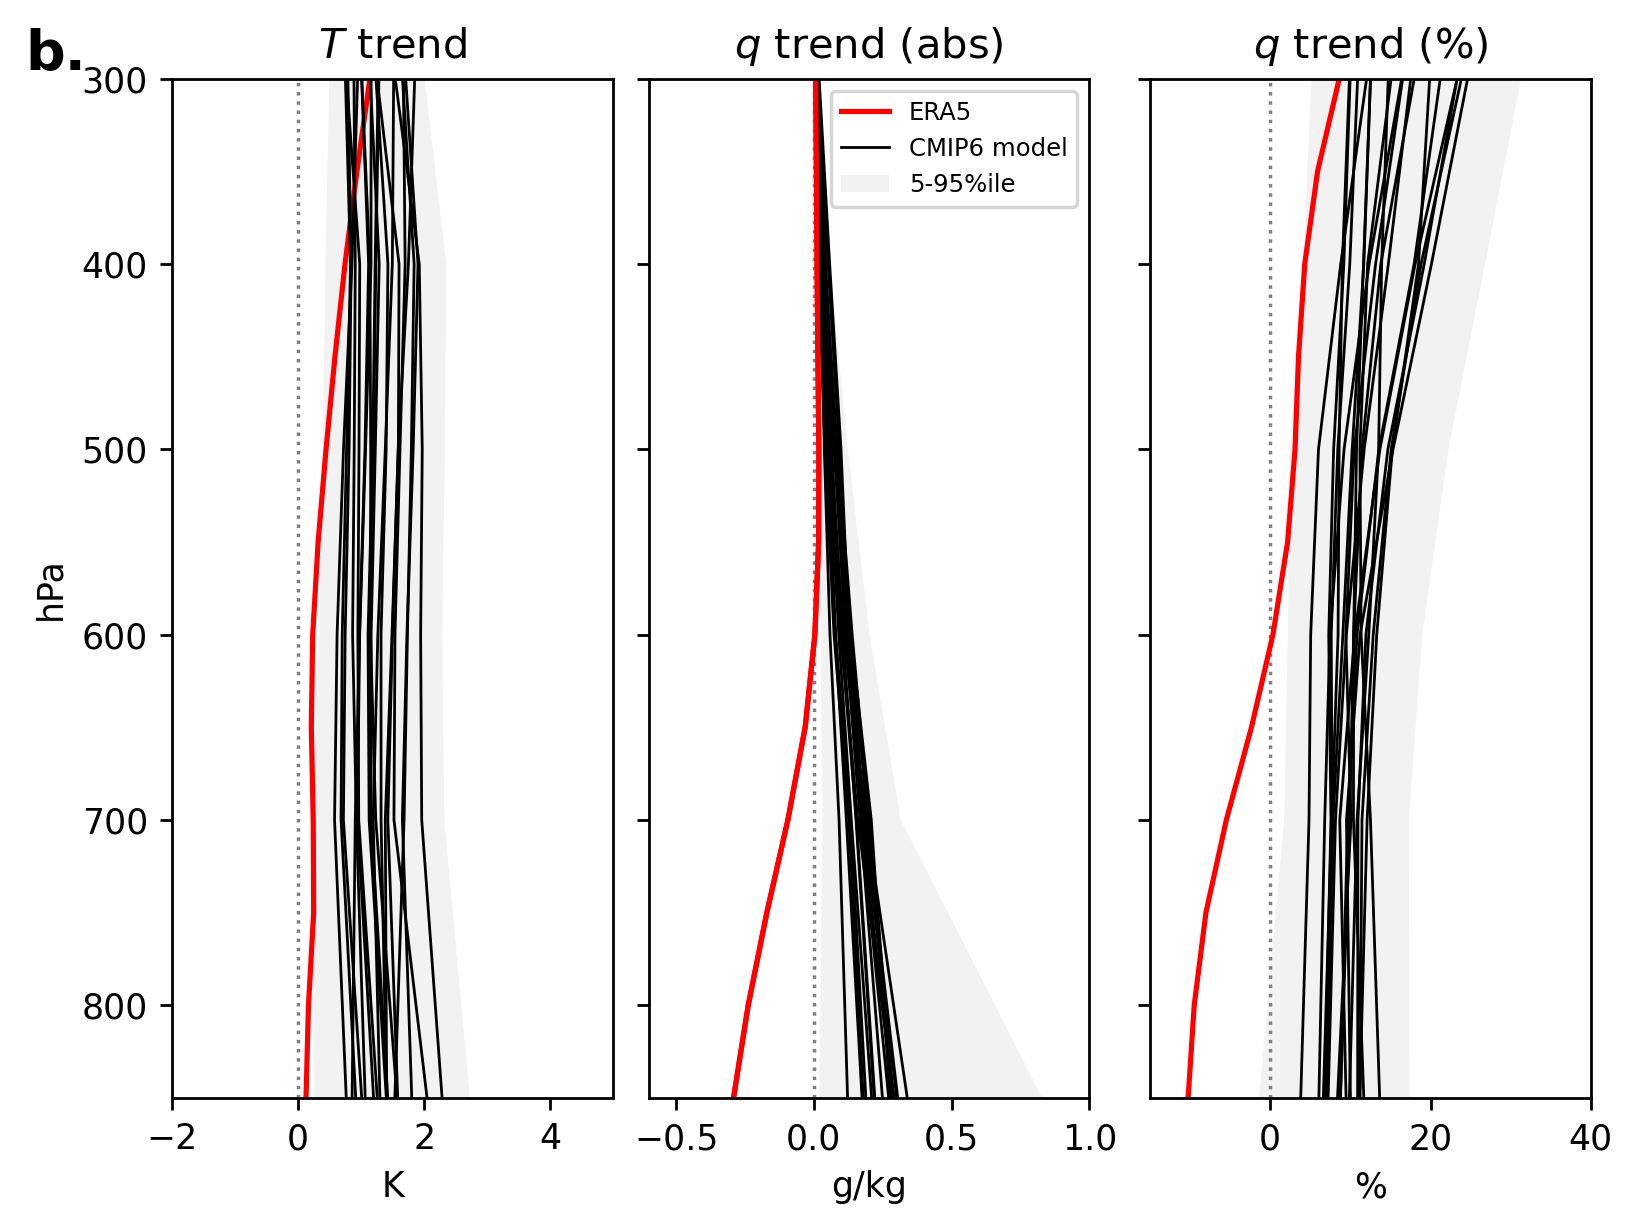

In [108]:
fig, axes = plt.subplots(1,3, sharey=True, dpi=250, layout="constrained")
ax = plt.subplot(1,3,1)
(45*era5_jfm).polyfit(dim='year', deg=1).sel(degree=1).t_polyfit_coefficients.plot(y='pressure_level', lw=1.5, c='r')

for model in list(modmembers_all_noGISS.keys()):
    if model == 'CESM2':(45*cmip6_ta_trends).sel(model=model).mean('member_id').ta_polyfit_coefficients.plot(y='pressure_level', lw=1, c='k')
    else: (45*cmip6_ta_trends).sel(model=model).mean('member_id').ta_polyfit_coefficients.plot(y='pressure_level', lw=0.8, c='k')
    #for member_id in modmembers_all[model]:
    #    (45*cmip6_ta_trends).sel(model=model, member_id=member_id).ta_polyfit_coefficients.plot(y='pressure_level', lw=0.05, c='grey')

lower = (45*cmip6_ta_trends).ta_polyfit_coefficients.quantile(q=.05, dim=['model', 'member_id'])
upper = (45*cmip6_ta_trends).ta_polyfit_coefficients.quantile(q=.95, dim=['model', 'member_id'])
ax.fill_betweenx(y=cmip6_ta_trends.pressure_level, x1=lower, x2=upper, alpha=0.1, facecolor='grey', label="5-95%ile")

ax.set_ylim(850,300)
ax.set_xlim(-2,5)
ax.axvline(0, lw=1, c='grey', zorder=0, ls=':')
ax.set_xlabel('K')
ax.set_ylabel('hPa')


ax.set_title('$T$ trend')

ax = plt.subplot(1,3,2)
(45*1000*era5_jfm).polyfit(dim='year', deg=1).sel(degree=1).q_polyfit_coefficients.plot(y='pressure_level', lw=1.5, c='r', label='ERA5')

for model in list(modmembers_all_noGISS.keys()):
    if model == 'CESM2':(45*1000*cmip6_hus_trends).sel(model=model).mean('member_id').hus_polyfit_coefficients.plot(y='pressure_level', lw=0.8, c='k',label='CMIP6 model')
    else: (45*1000*cmip6_hus_trends).sel(model=model).mean('member_id').hus_polyfit_coefficients.plot(y='pressure_level', lw=0.8, c='k')
    #for member_id in modmembers_all[model]:
        #(45*1000*cmip6_hus_trends).sel(model=model, member_id=member_id).hus_polyfit_coefficients.plot(y='pressure_level', lw=0.05, c='grey')
(45*1000*era5_jfm).polyfit(dim='year', deg=1).sel(degree=1).q_polyfit_coefficients.plot(y='pressure_level', lw=1.5, c='r')
lower = (45*1000*cmip6_hus_trends).hus_polyfit_coefficients.quantile(q=.05, dim=['model', 'member_id'])
upper = (45*1000*cmip6_hus_trends).hus_polyfit_coefficients.quantile(q=.95, dim=['model', 'member_id'])
ax.fill_betweenx(y=cmip6_hus_trends.pressure_level, x1=lower, x2=upper, alpha=0.1, facecolor='grey', label="5-95%ile")
ax.set_ylabel('')
ax.set_xlabel('g/kg')
ax.legend(loc='upper right', fontsize=7)
ax.axvline(0, lw=1, c='grey', zorder=0, ls=':')

ax.set_ylim(850,300)
ax.set_xlim(-.6,1)
ax.set_title('$q$ trend (abs)')

ax = plt.subplot(1,3,3)

for model in list(modmembers_all_noGISS.keys()):
    (45*100*cmip6_hus_trends_frac).sel(model=model).mean('member_id').hus.plot(y='pressure_level', lw=0.8, c='k')
    #for member_id in modmembers_all[model]:
        #(45*100*cmip6_hus_trends_frac).sel(model=model, member_id=member_id).hus.plot(y='pressure_level', lw=0.05, c='grey')
lower = (45*100*cmip6_hus_trends_frac).hus.quantile(q=.05, dim=['model', 'member_id'])
upper = (45*100*cmip6_hus_trends_frac).hus.quantile(q=.95, dim=['model', 'member_id'])
ax.fill_betweenx(y=cmip6_hus_trends_frac.pressure_level, x1=lower, x2=upper, alpha=0.1, facecolor='grey')
ax.axvline(0, lw=1, c='grey', zorder=0, ls=':')

(((45*100*era5_jfm).polyfit(dim='year', deg=1).sel(degree=1)).rename({'q_polyfit_coefficients':'q'})/era5_jfm_80_00_avg).q.plot(y='pressure_level', lw=1.5, c='r', label='ERA5')
ax.set_ylabel('')
ax.set_xlabel('%')
ax.set_ylim(850,300)
ax.set_xlim(-15,40)
ax.set_title('$q$ trend (%)')

fig.suptitle('b.', x=0.02, y=0.99, fontsize=16, fontweight='bold')